In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/clean_predicitve_dataset.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [2]:
df["temp_gap"] = (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

In [3]:
df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "temp_gap"
    ]
].head()

,Air temperature [K],Process temperature [K],temp_gap
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [4]:
df["temp_gap"].describe()

,temp_gap
count,10000.000000
mean,10.000630
std,1.001094
min,7.600000
25%,9.300000
50%,9.800000
75%,11.000000
max,12.100000


In [5]:
df.groupby(
    "Machine failure",

)["temp_gap"].mean()

,temp_gap
Machine failure,
0,10.021571
1,9.403835


In [6]:
df.groupby(
    "Machine failure",

)["temp_gap"].mean().median()

9.712703037087044

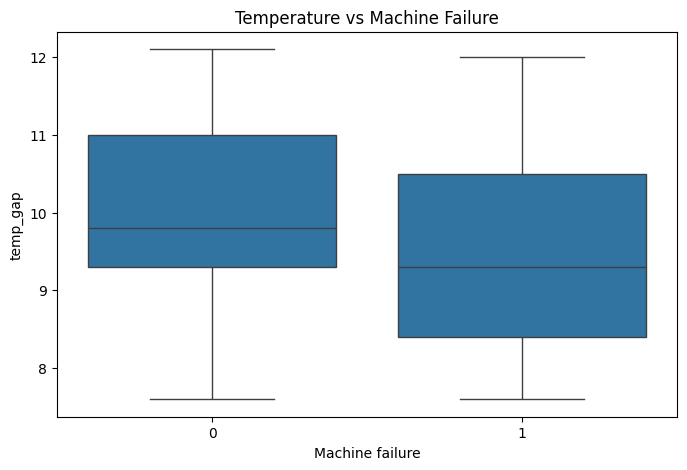

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="Machine failure",
    y="temp_gap",
    data=df
)

plt.title("Temperature vs Machine Failure")
plt.show()

In [8]:
df["temp_gap"].describe()

df.groupby("Machine failure")["temp_gap"].mean()

df.groupby("Machine failure")["temp_gap"].median()

,temp_gap
Machine failure,
0,9.8
1,9.3


Air temperature and process temperature were individually weak predictors.

To capture the relative heating effect of the machine, I engineered a temperature gap feature.

However, after validation, the feature showed only a weak relationship with machine failure and was not among the strongest predictors.

In [9]:
df["power"] = (
    df["Rotational speed [rpm]"]
    *
    df["Torque [Nm]"]
)

In [10]:
df[
    [
      "Rotational speed [rpm]",
      "Torque [Nm]",
      "power"
    ]
].head()

,Rotational speed [rpm],Torque [Nm],power
0,1551,42.8,66382.8
1,1408,46.3,65190.4
2,1498,49.4,74001.2
3,1433,39.5,56603.5
4,1408,40.0,56320.0


In [11]:
df["power"].describe()

,power
count,10000.000000
mean,59967.147040
std,10193.093881
min,10966.800000
25%,53105.400000
50%,59883.900000
75%,66873.750000
max,99980.400000


In [12]:
df.groupby(
    "Machine failure",

)["power"].mean()

,power
Machine failure,
0,59631.036446
1,69545.803245


In [13]:
df.groupby(
    "Machine failure"
)["power"].median()

,power
Machine failure,
0,59616.7
1,72683.8


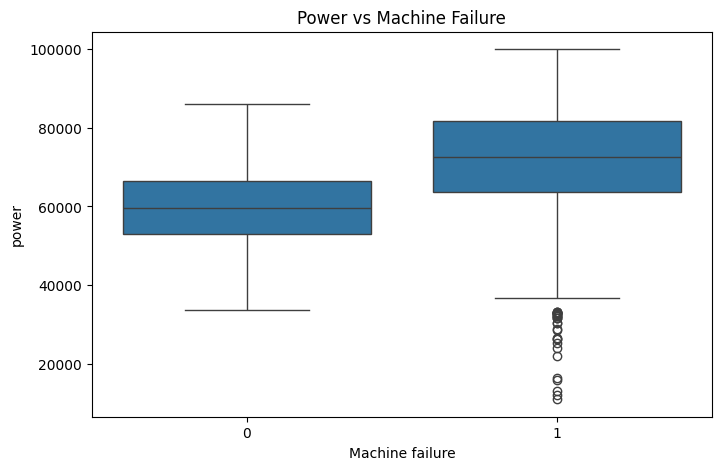

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="power",
    data=df
)

plt.title(
    "Power vs Machine Failure"
)

plt.show()

### Power Feature

A new feature called power was created using:

power = rotational_speed × torque

This feature represents the overall mechanical workload of the machine.

Analysis shows that failed machines operate under significantly higher power conditions compared to healthy machines.

Power appears to be a strong engineered feature for predicting machine failure.

In [15]:
df["wear_rate"] = (
    df["Tool wear [min]"]
    /
    df["Rotational speed [rpm]"]
)

In [16]:
df[
    [
        "Tool wear [min]",
        "Rotational speed [rpm]",
        "wear_rate"
    ]
].head()

,Tool wear [min],Rotational speed [rpm],wear_rate
0,0,1551,0.000000
1,3,1408,0.002131
2,5,1498,0.003338
3,7,1433,0.004885
4,9,1408,0.006392


In [17]:
df["wear_rate"].describe()

,wear_rate
count,10000.000000
mean,0.070965
std,0.042619
min,0.000000
25%,0.034545
50%,0.069993
75%,0.105679
max,0.185420


In [18]:
df.groupby(
    "Machine failure"
)["wear_rate"].mean()

,wear_rate
Machine failure,
0,0.069926
1,0.100589


In [19]:
df.groupby(
    "Machine failure"
)["wear_rate"].median()

,wear_rate
Machine failure,
0,0.069166
1,0.115702


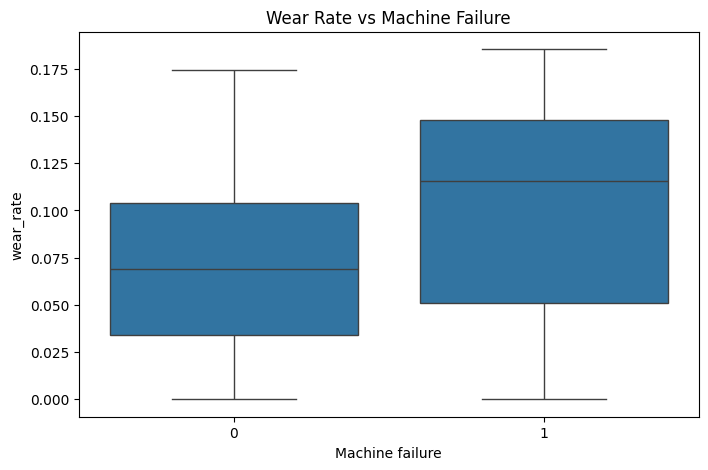

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="wear_rate",
    data=df
)

plt.title(
    "Wear Rate vs Machine Failure"
)

plt.show()

### Wear Rate Feature

A new feature called wear_rate was created using:

wear_rate = tool_wear / rotational_speed

This feature measures how quickly the machine accumulates wear relative to its operating speed.

Failed machines show significantly higher wear rates, suggesting abnormal degradation and increased mechanical stress.

Wear rate appears to be one of the strongest engineered features for machine failure prediction.

In [21]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,temp_gap,power,wear_rate
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,47318.0,0.008728
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,51897.6,0.010417
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,54943.0,0.013374
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,68288.0,0.017756


In [22]:
df["heat_stress"] = (
    df["temp_gap"]
    *
    df["Torque [Nm]"]
)

In [23]:
df[
    [
        "temp_gap",
        "Torque [Nm]",
        "heat_stress"
    ]
].head()

,temp_gap,Torque [Nm],heat_stress
0,10.5,42.8,449.40
1,10.5,46.3,486.15
2,10.4,49.4,513.76
3,10.4,39.5,410.80
4,10.5,40.0,420.00


In [24]:
df["heat_stress"].describe()

,heat_stress
count,10000.000000
mean,399.961047
std,107.725221
min,36.860000
25%,325.360000
50%,398.820000
75%,470.455000
max,857.920000


In [25]:
df.groupby(
    "Machine failure"
)["heat_stress"].mean()

,heat_stress
Machine failure,
0,397.470652
1,470.933628


In [26]:
df.groupby(
    "Machine failure"
)["heat_stress"].median()

,heat_stress
Machine failure,
0,396.52
1,471.44


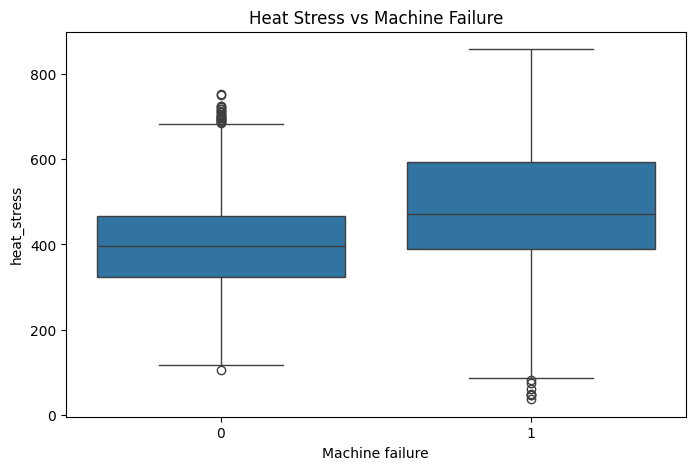

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="heat_stress",
    data=df
)

plt.title(
    "Heat Stress vs Machine Failure"
)

plt.show()

In [28]:
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Tool Wear Failure,Heat Dissipation Failure,Power Failure,Overstrain Failure,Random Failure,temp_gap,power,wear_rate,heat_stress
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000,449.40
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131,486.15
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338,513.76
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885,410.80
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392,420.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,47318.0,0.008728,283.20
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,51897.6,0.010417,302.10
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,54943.0,0.013374,320.64
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,68288.0,0.017756,470.45


In [29]:
df["stress_index"] = (
    df["power"]
    *
    df["wear_rate"]
)

In [30]:
df[
    [
        "power",
        "wear_rate",
        "stress_index"
    ]
].head()

,power,wear_rate,stress_index
0,66382.8,0.000000,0.0
1,65190.4,0.002131,138.9
2,74001.2,0.003338,247.0
3,56603.5,0.004885,276.5
4,56320.0,0.006392,360.0


In [31]:
df["stress_index"].describe()

,stress_index
count,10000.000000
mean,4314.664550
std,2826.567692
min,0.000000
25%,1963.650000
50%,4012.950000
75%,6279.000000
max,16497.000000


In [32]:
df.groupby(
    "Machine failure"
)["stress_index"].mean()

,stress_index
Machine failure,
0,4213.842708
1,7187.938348


In [33]:
df.groupby(
    "Machine failure"
)["stress_index"].median()

,stress_index
Machine failure,
0,3952.8
1,7681.8


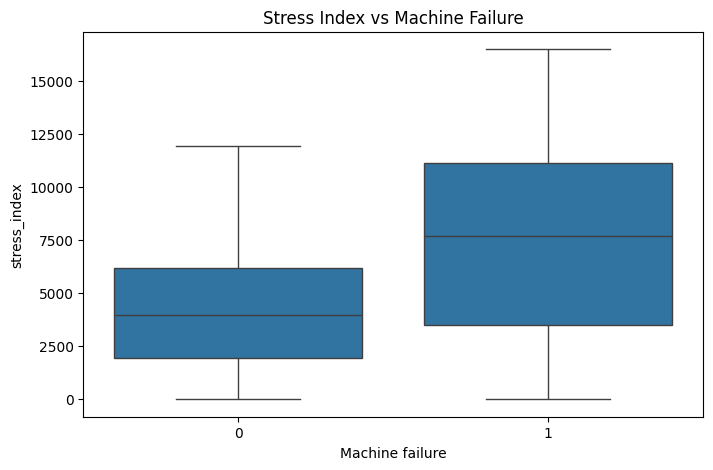

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Machine failure",
    y="stress_index",
    data=df
)

plt.title(
    "Stress Index vs Machine Failure"
)

plt.show()

In [35]:
df.groupby("Machine failure")["stress_index"].mean()

df.groupby("Machine failure")["stress_index"].median()

,stress_index
Machine failure,
0,3952.8
1,7681.8


# Notebook 03 Conclusion

Several engineered features were created using domain knowledge and insights obtained from exploratory data analysis.

The engineered features include:

- temp_gap
- power
- wear_rate
- heat_stress
- stress_index

Among them, power, wear_rate, heat_stress, and stress_index demonstrated stronger separation between healthy and failed machines than many original features.

These engineered features are expected to improve machine learning model performance by capturing complex machine operating conditions that are not directly represented by the original variables.

In [36]:
df.to_csv(
    "feature_engineered_data.csv",
    index=False
)

print("Notebook 03 Saved Successfully")

Notebook 03 Saved Successfully
